In [57]:
import pandas as pd
    
data = pd.read_csv('used_cars.csv')

In [58]:
data

,year_bought,km_driven,transmission,owner,selling_price
0,2011.0,159736.0,Manual,Third,4928.821782
1,2019.0,72172.0,Automatic,Third,12699.765188
2,2015.0,98264.0,Automatic,First,9492.131132
3,2012.0,31736.0,Automatic,First,9914.594542
4,2011.0,117859.0,Manual,First,6767.338316
...,...,...,...,...,...
146,2021.0,192907.0,Manual,Third,6861.568872
147,2021.0,107946.0,Automatic,First,11339.476674
148,2016.0,114616.0,Manual,First,9058.522569
149,2011.0,110983.0,Automatic,Third,5291.699915


In [59]:
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

In [60]:
# Data Cleaning 
import numpy as np

# Converting to Numeric Value
data['year_bought'] = pd.to_numeric(data['year_bought'],errors='coerce')
data['km_driven'] = pd.to_numeric(data['km_driven'], errors='coerce') 
data['selling_price'] = pd.to_numeric(data['selling_price'], errors='coerce')

# Handling Missing values 
data['year_bought'].fillna(data['year_bought'].mean(), inplace=True)
data['km_driven'].fillna(data['km_driven'].mean(), inplace=True)
data['selling_price'].fillna(data['selling_price'].mean(), inplace=True) 

In [61]:
data

,year_bought,km_driven,transmission,owner,selling_price
0,2011.0,159736.0,Manual,Third,4928.821782
1,2019.0,72172.0,Automatic,Third,12699.765188
2,2015.0,98264.0,Automatic,First,9492.131132
3,2012.0,31736.0,Automatic,First,9914.594542
4,2011.0,117859.0,Manual,First,6767.338316
...,...,...,...,...,...
146,2021.0,192907.0,Manual,Third,6861.568872
147,2021.0,107946.0,Automatic,First,11339.476674
148,2016.0,114616.0,Manual,First,9058.522569
149,2011.0,110983.0,Automatic,Third,5291.699915


In [62]:
# fix unrealistic  values 
data.loc[data['km_driven'] < 0, 'km_driven'] = data['km_driven'].mean()

# Replace invalid owner
data.loc[~data['owner'].isin(['First', 'Second', 'Third']), 'owner'] = 'Second'

# Remove duplicates
data.drop_duplicates(inplace=True)

print("Data cleaned successfully!\n")
print(data.head())

Data cleaned successfully!

   year_bought  km_driven transmission  owner  selling_price
0       2011.0   159736.0       Manual  Third    4928.821782
1       2019.0    72172.0    Automatic  Third   12699.765188
2       2015.0    98264.0    Automatic  First    9492.131132
3       2012.0    31736.0    Automatic  First    9914.594542
4       2011.0   117859.0       Manual  First    6767.338316


In [63]:
# check if any missing value remaining 
data.isnull().sum()

year_bought      0
km_driven        0
transmission     0
owner            0
selling_price    0
dtype: int64

Text(0.5, 1.0, 'Scattar Plot (year_bought VS selling_price) ')

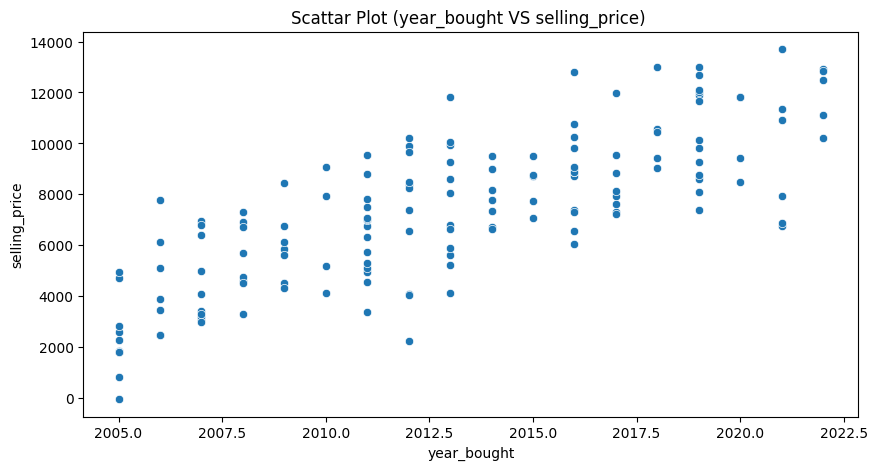

In [64]:
# Visulaize Data 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.scatterplot(x='year_bought', y='selling_price', data=data)
plt.title("Scattar Plot (year_bought VS selling_price) ")


Text(0.5, 1.0, 'Scattar Plot (km_driven VS selling_price)')

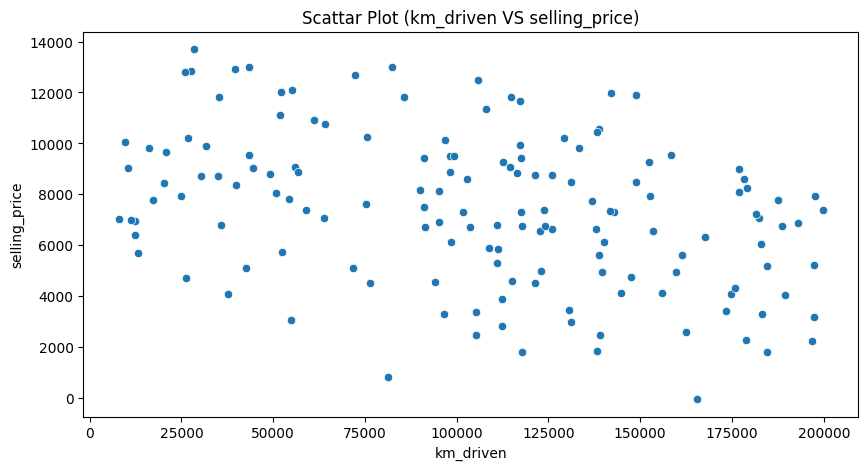

In [65]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='km_driven', y='selling_price', data=data)
plt.title("Scattar Plot (km_driven VS selling_price)")

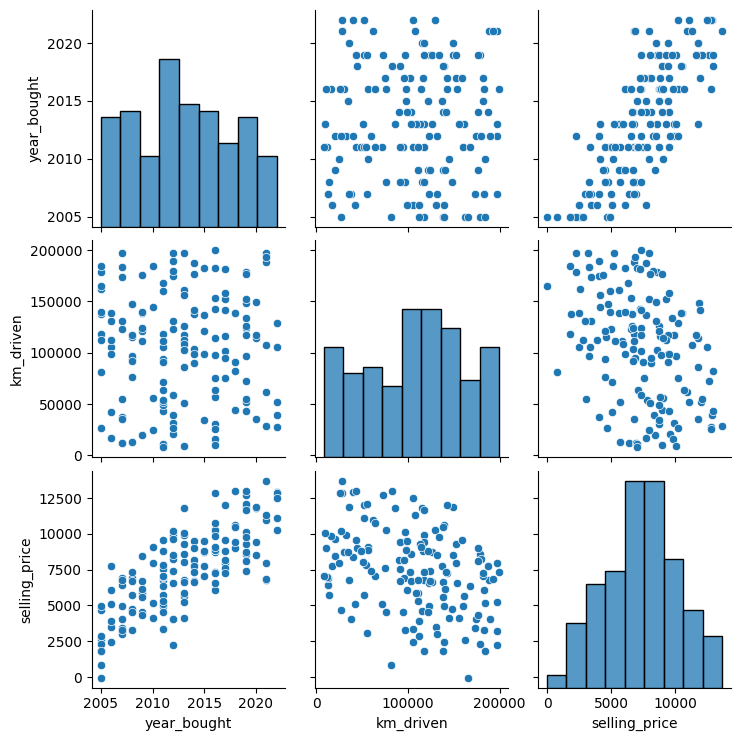

In [66]:
import seaborn as sns
sns.pairplot(data)

In [67]:
# Calculate correlation only for numeric columns
data.select_dtypes(include=[np.number]).corr()

,year_bought,km_driven,selling_price
year_bought,1.000000,0.012808,0.782714
km_driven,0.012808,1.000000,-0.375879
selling_price,0.782714,-0.375879,1.000000


In [68]:
# Build Regression Model (Multiple Linear Regression)
# Predict selling_price based on year_bought & km_driven (no sklearn)

X1 = data['year_bought'].values
X2 = data['km_driven'].values
y = data['selling_price'].values

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Prepare features matrix
X = np.column_stack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [70]:
X

array([[  2011.        , 159736.        ],
       [  2019.        ,  72172.        ],
       [  2015.        ,  98264.        ],
       [  2012.        ,  31736.        ],
       [  2011.        , 117859.        ],
       [  2013.        , 117181.        ],
       [  2015.        , 136926.        ],
       [  2008.        ,  95084.        ],
       [  2012.        , 174695.        ],
       [  2007.        ,  12392.        ],
       [  2006.        , 105234.59333333],
       [  2016.        , 182789.        ],
       [  2010.        ,  55859.        ],
       [  2006.        , 130657.        ],
       [  2005.        , 162381.        ],
       [  2016.        , 199806.        ],
       [  2016.        ,  75467.        ],
       [  2021.        , 188734.        ],
       [  2014.        , 103506.        ],
       [  2020.        , 114751.        ],
       [  2019.        , 123906.        ],
       [  2019.        , 148760.        ],
       [  2016.        ,  30342.        ],
       [  2

In [73]:
X_train

array([[  2016.        ,  30342.        ],
       [  2016.        , 199806.        ],
       [  2017.        , 101601.        ],
       [  2016.        , 182789.        ],
       [  2008.        , 117547.        ],
       [  2021.        , 192907.        ],
       [  2016.        ,  16111.        ],
       [  2011.        ,  94045.        ],
       [  2011.        , 117859.        ],
       [  2013.        , 161256.        ],
       [  2014.        , 141672.        ],
       [  2011.        ,  11295.        ],
       [  2013.        , 125885.        ],
       [  2016.        ,  75467.        ],
       [  2006.        , 105234.59333333],
       [  2009.        ,  20151.        ],
       [  2017.        , 141967.        ],
       [  2010.        , 184476.        ],
       [  2015.        ,  34855.        ],
       [  2019.        , 117296.        ],
       [  2007.        , 197339.        ],
       [  2018.        ,  82505.        ],
       [  2013.        , 112512.        ],
       [  2

In [75]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [76]:
X_train

array([[ 0.64724276, -1.39782595],
       [ 0.64724276,  1.68736407],
       [ 0.85547099, -0.10051469],
       [ 0.64724276,  1.37755975],
       [-1.01858311,  0.18979145],
       [ 1.68838393,  1.56176379],
       [ 0.64724276, -1.65690953],
       [-0.39389841, -0.23807604],
       [-0.39389841,  0.19547159],
       [ 0.02255806,  0.98553905],
       [ 0.23078629,  0.62900101],
       [-0.39389841, -1.74458759],
       [ 0.02255806,  0.34158956],
       [ 0.64724276, -0.57629926],
       [-1.43503958, -0.03436303],
       [-0.81035488, -1.583359  ],
       [ 0.85547099,  0.63437166],
       [-0.60212664,  1.40827256],
       [ 0.43901453, -1.31566418],
       [ 1.27192746,  0.18522185],
       [-1.22681135,  1.64245091],
       [ 1.06369923, -0.4481684 ],
       [ 0.02255806,  0.09812637],
       [-0.39389841,  0.95786657],
       [-0.39389841, -1.05698113],
       [ 1.27192746,  0.82509329],
       [ 1.89661216, -1.22749457],
       [ 1.06369923,  0.57822566],
       [-0.18567018,

In [71]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:

# Make predictions
y_pred = model.predict(X_test)


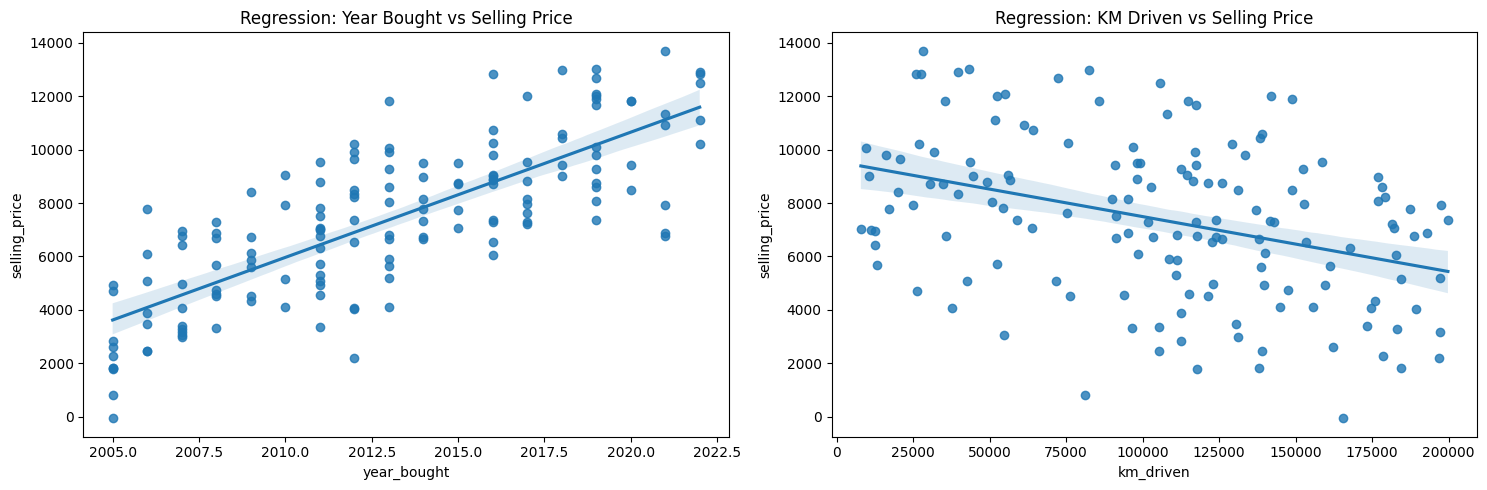

In [74]:
# Plot regression line for each feature separately
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot for year_bought
sns.regplot(x='year_bought', y='selling_price', data=data, ax=axes[0])
axes[0].set_title("Regression: Year Bought vs Selling Price")

# Plot for km_driven
sns.regplot(x='km_driven', y='selling_price', data=data, ax=axes[1])
axes[1].set_title("Regression: KM Driven vs Selling Price")

plt.tight_layout()
plt.show()

In [77]:
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Mean Squared Error: 2222840.9109414527
Coefficients: [ 4.77176234e+02 -2.07417875e-02]
Intercept: -951013.3111017394


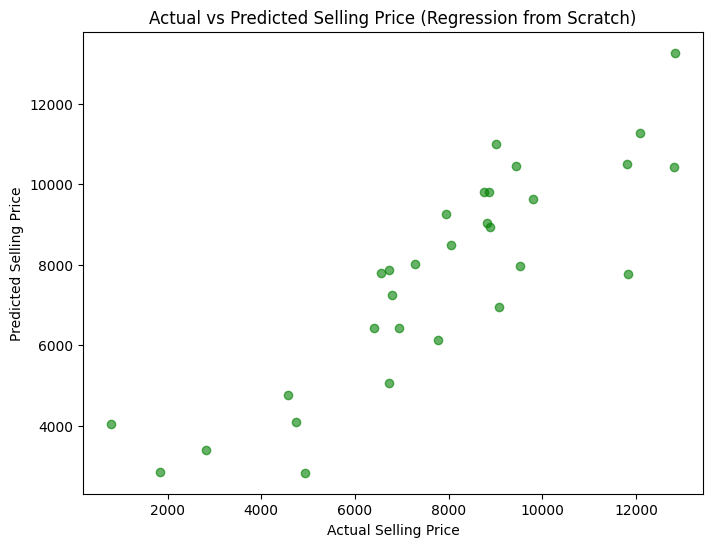

In [78]:
# Visualize Predictions
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Regression from Scratch)")
plt.show()

In [80]:
import numpy as np
# Evaluate Model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)

In [81]:
print("\n--- Model Evaluation ---")
print(f"Coefficient (Radio): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


--- Model Evaluation ---
Coefficient (Radio): 477.1762
Intercept: -951013.3111
R² Score: -104634.1624
RMSE: 1490.9195
